In [ ]:
#MACHINE LEARNING
#LINEAR REGRESSION

In [ ]:
import seaborn as sns
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


<Axes: ylabel='tip'>

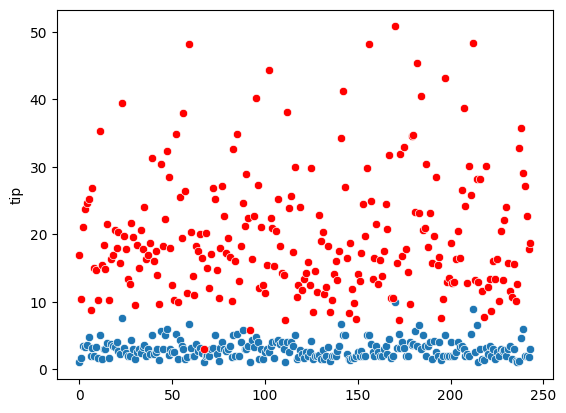

In [ ]:
sns.scatterplot(df['tip'])
sns.scatterplot(df['total_bill'],color='red')

<Axes: xlabel='tip', ylabel='total_bill'>

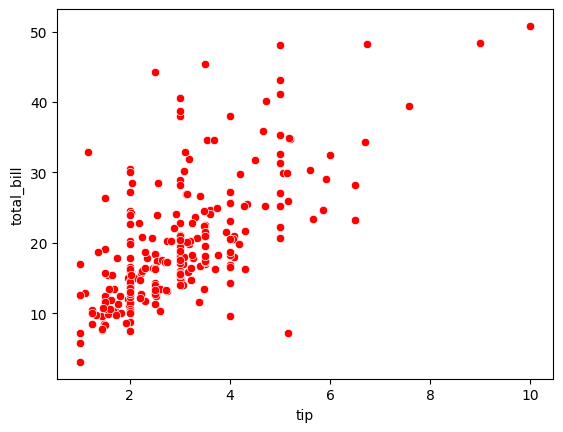

In [ ]:
sns.scatterplot(x='tip',y='total_bill',color='red',data=df)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
a=['sex','smoker','day','time']
for i in a:
  df[i] = le.fit_transform(df[i])

In [ ]:
x=df.drop('tip',axis=1)
y=df['tip']

In [ ]:
#SPLITTING DATA FOR TRAINING
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
#TRAINING MODEL
from sklearn.linear_model import LinearRegression
a=LinearRegression()
model=a.fit(x_train,y_train)


In [ ]:
#EVALUATION METHOD
# R SQUARE METHOD
y_pred=model.predict(x_test)
r2=model.score(x_test,y_test)
print("R square:",r2)

R square: 0.34706959280474403


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(x_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.34706959280474403
MAE: 0.7006905273520015
MSE: 0.8686748273229006
RMSE: 0.932027267478211


In [ ]:
import pandas as pd
comparision=pd.DataFrame({"actual":y_test.values,"predicted":y_pred})
print(comparision)

    actual  predicted
0     3.18   3.019084
1     2.00   1.867574
2     2.00   3.866842
3     5.16   3.765232
4     2.00   2.104012
..     ...        ...
56    5.15   1.434374
57    1.75   2.818859
58    2.74   2.927275
59    3.00   2.534338
60    5.14   4.576719

[61 rows x 2 columns]


In [ ]:
# RETRAINING THE REGRESSION MODEL

In [ ]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("tips")
df = pd.get_dummies(df, columns=['sex','smoker','day','time'], drop_first=True)
x = df.drop('tip', axis=1)
y = df['tip']
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.25, random_state=42)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

print("R2:", model.score(x_test, y_test))


R2: 0.3504334496770186


In [ ]:
x = df.drop('tip', axis=1)
y = df['tip']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

print("R2:", model.score(x_test, y_test))

R2: 0.3504334496770186


In [ ]:
#validatin
from sklearn.model_selection import cross_val_score
import numpy as np

model = LinearRegression()

scores = cross_val_score(model, x, y, cv=5, scoring='r2')

print("R2 scores for 5 folds:", scores)
print("Average R2:", np.mean(scores))

R2 scores for 5 folds: [0.52819606 0.59245311 0.40773384 0.20031853 0.37843167]
Average R2: 0.4214266405944052


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

print("Test R2:", rf.score(x_test, y_test))

Test R2: 0.21478122490410434


In [ ]:
scores = cross_val_score(rf, x, y, cv=5, scoring='r2')
print("RF CV Scores:", scores)
print("RF Average:", scores.mean())

RF CV Scores: [0.37188346 0.52574477 0.50073632 0.18935641 0.36108341]
RF Average: 0.38976087357068157


In [ ]:
print("Train R2:", rf.score(x_train, y_train))
print("Test R2:", rf.score(x_test, y_test))

Train R2: 0.9221806669876823
Test R2: 0.21478122490410434


In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=200, random_state=42)

scores = cross_val_score(rf, x, y, cv=5, scoring='r2')

print("RF CV Scores:", scores)
print("RF Average:", scores.mean())

RF CV Scores: [0.37188346 0.52574477 0.50073632 0.18935641 0.36108341]
RF Average: 0.38976087357068157


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

# Separate X and y again
x = df.drop('tip', axis=1)
y = df['tip']

# Only select total_bill for polynomial expansion
poly = PolynomialFeatures(degree=2, include_bias=False)

total_bill_poly = poly.fit_transform(x[['total_bill']])

# Convert to dataframe
poly_df = pd.DataFrame(
    total_bill_poly,
    columns=['total_bill', 'total_bill_squared']
)

# Drop original total_bill
x_new = x.drop('total_bill', axis=1)

# Add polynomial columns
x_new = pd.concat([x_new.reset_index(drop=True),
                   poly_df.reset_index(drop=True)], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.25, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model_poly = LinearRegression()
model_poly.fit(x_train, y_train)

print("Test R2:", model_poly.score(x_test, y_test))

Test R2: 0.3457086748459747


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model_poly, x_new, y, cv=5, scoring='r2')

print("Polynomial CV Scores:", scores)
print("Polynomial Average:", np.mean(scores))

Polynomial CV Scores: [0.52150175 0.57254321 0.37020134 0.18903958 0.36062074]
Polynomial Average: 0.4027813258519222
